# import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline
import  re 
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,r2_score,root_mean_squared_error,mean_absolute_error
import datetime

# load data

In [2]:
data=pd.read_csv("carprice_ml_pro.csv")
df=pd.DataFrame(data)
df

,it,ft,bt,km,transmission,ownerNo,owner,oem,model,modelYear,...,Cargo Volumn,Alloy Wheel Size_2,City,Gear Box_1,Rear Brake Type_1,Front Brake Type_1,Acceleration_1,Top Speed_1,Drive Type_1,Turning Radius_1
0,0,Petrol,Hatchback,"1,20,000",Manual,3,3rd Owner,Maruti,Maruti Celerio,2015,...,235-litres,NaN,Bangalore,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,Petrol,SUV,"32,706",Manual,2,2nd Owner,Ford,Ford Ecosport,2018,...,352-litres,16,Bangalore,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,Petrol,Hatchback,"11,949",Manual,1,1st Owner,Tata,Tata Tiago,2018,...,242-litres,14,Bangalore,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,Petrol,Sedan,"17,794",Manual,1,1st Owner,Hyundai,Hyundai Xcent,2014,...,407-litres,14,Bangalore,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,Diesel,SUV,"60,000",Manual,1,1st Owner,Maruti,Maruti SX4 S Cross,2015,...,353-litres,16,Bangalore,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8364,0,Petrol,Hatchback,"10,000",Manual,1,1st Owner,Maruti,Maruti Celerio,2022,...,313,NaN,Kolkata,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8365,0,Petrol,Hatchback,"1,20,000",Manual,1,1st Owner,Maruti,Maruti Alto 800,2014,...,177-litres,NaN,Kolkata,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8366,0,Petrol,Sedan,"50,000",Automatic,3,3rd Owner,Mercedes-Benz,Mercedes-Benz C-Class,2011,...,475-litres,NaN,Kolkata,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8367,0,Petrol,Hatchback,"40,000",Manual,1,1st Owner,Maruti,Maruti Ritz,2012,...,236-liters,NaN,Kolkata,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# find new features

In [3]:
current_year=datetime.datetime.now().year
current_year

2025

In [4]:
df["Car Age"]=current_year-df["modelYear"]
df["Car Age"]

0       10
1        7
2        7
3       11
4       10
        ..
8364     3
8365    11
8366    14
8367    13
8368     8
Name: Car Age, Length: 8369, dtype: int64

In [5]:
df["Length"]=df["Length"].str.replace("mm","").str.replace(",","").str.strip().astype(float)
df["Width"]=df["Width"].str.replace("mm","").str.replace(",","").str.strip().astype(float)
df["Height"]=df["Height"].str.replace("mm","").str.replace(",","").str.replace("-","").str.strip().astype(float)

In [6]:
df["Car Size"]=df["Length"]*df["Width"]*df["Height"]
df["Car Size"].unique()

array([9.50584912e+09, 1.16220061e+10, 9.47043117e+09, 1.00801840e+10,
       1.22424225e+10, 1.31037804e+10, 9.22082775e+09, 1.13491958e+10,
       1.15350345e+10, 1.05266252e+10, 9.49984800e+09, 1.03444449e+10,
       1.54681852e+10, 1.44357199e+10, 1.02813322e+10, 1.16135047e+10,
       1.12510710e+10, 1.31187614e+10, 1.02067448e+10, 1.34649444e+10,
       1.66939261e+10, 9.26398200e+09, 8.64423375e+09, 1.40692669e+10,
       1.36849871e+10, 1.31335956e+10, 9.14685850e+09, 1.28867992e+10,
       1.36495682e+10, 1.53841102e+10, 1.59817800e+10, 1.03995350e+10,
       1.18199025e+10, 1.34506631e+10, 7.69828312e+09, 1.58973872e+10,
       9.40161530e+09, 1.27767150e+10, 1.56674131e+10, 7.52648250e+09,
       2.02795520e+10, 1.57666901e+10, 1.92437940e+10, 8.68370103e+09,
       1.16236463e+10, 9.61062975e+09, 9.50917488e+09, 1.09243593e+10,
       1.23889780e+10, 1.48568921e+10, 1.01934720e+10, 1.32979542e+10,
       1.33655686e+10, 1.25037569e+10, 1.02740400e+10, 1.06721431e+10,
      

In [7]:
selected_feature=['Car Age','Car Size','ft', 'bt', 'km', 'transmission', 'ownerNo','oem',
                  'model', 'modelYear', 'price','Insurance Validity','Mileage', 'Engine',
                  ' Seats','Color','City']


# drop unwamted columns

In [8]:
new_df=df.drop(columns=['it', 'owner',  'centralVariantId', 'variantName',
       'priceActual', 'priceSaving', 'priceFixedText', 'trendingText.imgUrl',
       'trendingText.heading', 'trendingText.desc', 'Registration Year',
       'Fuel Type', 'Kms Driven', 'RTO',
       'Ownership', 'Engine Displacement', 'Transmission',
       'Year of Manufacture', 'Max Power', 'Torque',
       'Seats_1', 'Wheel Size', 'Engine Type', 'Displacement',
       'Max Power_1', 'Max Torque', 'No of Cylinder', 'Values per Cylinder',
       'Value Configuration', 'Fuel Suppy System', 'BoreX Stroke',
       'Compression Ratio', 'Turbo Charger', 'Super Charger',
       'Seating Capacity', 'Steering Type', 'Tyre Type', 'Alloy Wheel Size',
       'No Door Numbers', 'Length', 'Width', 'Height', 'Wheel Base',
       'Front Tread', 'Rear Tread', 'Kerb Weight', 'Gross Weight',
       'Ground Clearance Unladen', 'Seating Capacity_1', 'Steering Type_1',
       'Tyre Type_1', 'Alloy Wheel Size_1', 'No Door Numbers_1', 'Gear Box',
       'Drive Type', 'Seating Capacity_2', 'Steering Type_2', 'Turning Radius',
       'Front Brake Type', 'Rear Brake Type', 'Top Speed', 'Acceleration',
       'Tyre Type_2', 'No Door Numbers_2', 'Cargo Volumn',
       'Alloy Wheel Size_2', 'Gear Box_1', 'Rear Brake Type_1',
       'Front Brake Type_1', 'Acceleration_1', 'Top Speed_1', 'Drive Type_1',
       'Turning Radius_1'],inplace=True)
new_df

In [9]:
df.columns

Index(['ft', 'bt', 'km', 'transmission', 'ownerNo', 'oem', 'model',
       'modelYear', 'price', 'Insurance Validity', 'Seats', 'Mileage',
       'Engine', 'Color', 'City', 'Car Age', 'Car Size'],
      dtype='object')

# remove strings from numerical columns

In [10]:
df["km"]=df["km"].str.replace(",","").str.strip().astype(float)
df["Insurance Validity"]=df["Insurance Validity"].str.replace("2","Second Party").str.replace("1","First Party").str.strip()
df["Seats"]=df["Seats"].str.replace("Seats","").str.strip().astype(float)
df["Mileage"]=df["Mileage"].str.replace("kmpl","").str.replace("km/kg",'').str.strip().astype(float)
df["Engine"]=df["Engine"].str.replace("CC","").str.strip().astype(float)
df["price"]=df["price"].str.replace("Lakh","").str.replace("Crore","").str.replace(",","").str.replace("₹","").str.strip().astype(float)

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df.isnull().sum()

ft                      0
bt                      4
km                      0
transmission            0
ownerNo                 0
oem                     0
model                   0
modelYear               0
price                   0
Insurance Validity      4
Seats                   6
Mileage               284
Engine                  4
Color                   3
City                    0
Car Age                 0
Car Size               83
dtype: int64

# drop maximum null values presented rows

In [13]:
df.dropna(subset=["Mileage"],inplace=True)
df.shape

(7975, 17)

In [14]:
df.dropna(subset=["Car Size"],inplace=True)
df.shape

(7915, 17)

# fill missing values

In [15]:
df["bt"].fillna(df["bt"].mode()[0],inplace=True)
df["Insurance Validity"].fillna(df["Insurance Validity"].mode()[0],inplace=True)
df["Seats"].fillna(df["Seats"].median(),inplace=True)
df["Engine"].fillna(df["Engine"].mode()[0],inplace=True)
df["Color"].fillna(df["Color"].mode()[0],inplace=True)

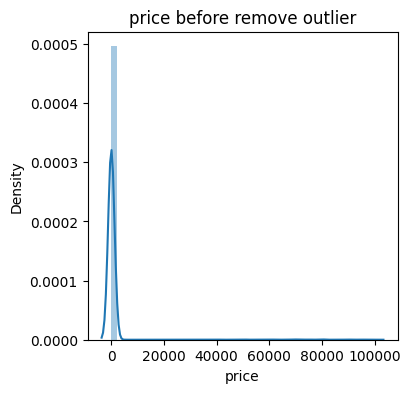

In [16]:
plt.figure(figsize=(4,4))
sns.distplot(df["price"])
plt.title("price before remove outlier")
plt.show()

# handle outliers

In [17]:
q1=df["price"].quantile(0.25)
q3=df["price"].quantile(0.75)
iqr=q3-q1
lf=q1-1.5*iqr
uf=q3+1.5*iqr
dff=df[(df["price"]>lf)&(df['price']<uf)]
dff

,ft,bt,km,transmission,ownerNo,oem,model,modelYear,price,Insurance Validity,Seats,Mileage,Engine,Color,City,Car Age,Car Size
0,Petrol,Hatchback,120000.0,Manual,3,Maruti,Maruti Celerio,2015,4.00,Third Party insurance,5.0,23.10,998.0,White,Bangalore,10,9.505849e+09
1,Petrol,SUV,32706.0,Manual,2,Ford,Ford Ecosport,2018,8.11,Comprehensive,5.0,17.00,1497.0,White,Bangalore,7,1.162201e+10
2,Petrol,Hatchback,11949.0,Manual,1,Tata,Tata Tiago,2018,5.85,Comprehensive,5.0,23.84,1199.0,Red,Bangalore,7,9.470431e+09
3,Petrol,Sedan,17794.0,Manual,1,Hyundai,Hyundai Xcent,2014,4.62,Comprehensive,5.0,19.10,1197.0,Others,Bangalore,11,1.008018e+10
4,Diesel,SUV,60000.0,Manual,1,Maruti,Maruti SX4 S Cross,2015,7.90,Third Party insurance,5.0,23.65,1248.0,Gray,Bangalore,10,1.224242e+10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8364,Petrol,Hatchback,10000.0,Manual,1,Maruti,Maruti Celerio,2022,5.10,Third Party insurance,5.0,25.24,998.0,Others,Kolkata,3,9.509175e+09
8365,Petrol,Hatchback,120000.0,Manual,1,Maruti,Maruti Alto 800,2014,1.80,Third Party insurance,5.0,22.74,796.0,Others,Kolkata,11,7.461361e+09
8366,Petrol,Sedan,50000.0,Automatic,3,Mercedes-Benz,Mercedes-Benz C-Class,2011,5.50,Third Party insurance,5.0,11.74,1796.0,Others,Kolkata,14,1.175842e+10
8367,Petrol,Hatchback,40000.0,Manual,1,Maruti,Maruti Ritz,2012,1.40,Third Party insurance,5.0,18.50,1197.0,Others,Kolkata,13,1.027404e+10


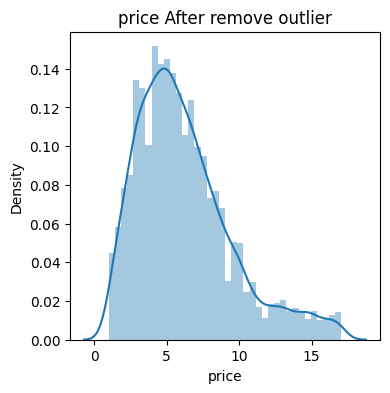

In [18]:
plt.figure(figsize=(4,4))
sns.distplot(dff["price"])
plt.title("price After remove outlier")
plt.show()

# rename columns

In [19]:
dff=dff.rename(columns={"ft":"Fuel Type","bt":"Body Type","transmission":"Transmission","ownerNo":"Owner No","model":"Model",
                        "modelYear":"Model Year","price":"Price","km":"Kilometer","oem":"Brand"})
dff

,Fuel Type,Body Type,Kilometer,Transmission,Owner No,Brand,Model,Model Year,Price,Insurance Validity,Seats,Mileage,Engine,Color,City,Car Age,Car Size
0,Petrol,Hatchback,120000.0,Manual,3,Maruti,Maruti Celerio,2015,4.00,Third Party insurance,5.0,23.10,998.0,White,Bangalore,10,9.505849e+09
1,Petrol,SUV,32706.0,Manual,2,Ford,Ford Ecosport,2018,8.11,Comprehensive,5.0,17.00,1497.0,White,Bangalore,7,1.162201e+10
2,Petrol,Hatchback,11949.0,Manual,1,Tata,Tata Tiago,2018,5.85,Comprehensive,5.0,23.84,1199.0,Red,Bangalore,7,9.470431e+09
3,Petrol,Sedan,17794.0,Manual,1,Hyundai,Hyundai Xcent,2014,4.62,Comprehensive,5.0,19.10,1197.0,Others,Bangalore,11,1.008018e+10
4,Diesel,SUV,60000.0,Manual,1,Maruti,Maruti SX4 S Cross,2015,7.90,Third Party insurance,5.0,23.65,1248.0,Gray,Bangalore,10,1.224242e+10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8364,Petrol,Hatchback,10000.0,Manual,1,Maruti,Maruti Celerio,2022,5.10,Third Party insurance,5.0,25.24,998.0,Others,Kolkata,3,9.509175e+09
8365,Petrol,Hatchback,120000.0,Manual,1,Maruti,Maruti Alto 800,2014,1.80,Third Party insurance,5.0,22.74,796.0,Others,Kolkata,11,7.461361e+09
8366,Petrol,Sedan,50000.0,Automatic,3,Mercedes-Benz,Mercedes-Benz C-Class,2011,5.50,Third Party insurance,5.0,11.74,1796.0,Others,Kolkata,14,1.175842e+10
8367,Petrol,Hatchback,40000.0,Manual,1,Maruti,Maruti Ritz,2012,1.40,Third Party insurance,5.0,18.50,1197.0,Others,Kolkata,13,1.027404e+10


# label encoding for categorical features

In [20]:
le=LabelEncoder()
dff["Fuel Type"]=le.fit_transform(dff["Fuel Type"])
dff["Body Type"]=le.fit_transform(dff["Body Type"])
dff["Transmission"]=le.fit_transform(dff["Transmission"])
dff["Brand"]=le.fit_transform(dff["Brand"])
dff["Model"]=le.fit_transform(dff["Model"])
dff["Color"]=le.fit_transform(dff["Color"])
dff["Insurance Validity"]=le.fit_transform(dff["Insurance Validity"])
dff["City"]=le.fit_transform(dff["City"])
dff.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7046 entries, 0 to 8368
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Fuel Type           7046 non-null   int64  
 1   Body Type           7046 non-null   int64  
 2   Kilometer           7046 non-null   float64
 3   Transmission        7046 non-null   int64  
 4   Owner No            7046 non-null   int64  
 5   Brand               7046 non-null   int64  
 6   Model               7046 non-null   int64  
 7   Model Year          7046 non-null   int64  
 8   Price               7046 non-null   float64
 9   Insurance Validity  7046 non-null   int64  
 10  Seats               7046 non-null   float64
 11  Mileage             7046 non-null   float64
 12  Engine              7046 non-null   float64
 13  Color               7046 non-null   int64  
 14  City                7046 non-null   int64  
 15  Car Age             7046 non-null   int64  
 16  Car Size   

# split target and features

In [21]:
x=dff.drop("Price",axis=1)
y=dff["Price"]

In [22]:
x.shape,y.shape

((7046, 16), (7046,))

# features scaling

In [23]:
std=StandardScaler()
x_scaled=std.fit_transform(x)
x_scaled.shape

(7046, 16)

# split data for train and test

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,test_size=0.2,random_state=42)
x_train.shape

(5636, 16)

In [26]:
x_test.shape

(1410, 16)

# model train

In [27]:
model_rf=RandomForestRegressor()
model_rf.fit(x_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [28]:
y_pred_rf=model_rf.predict(x_test)
y_pred_rf

array([2.6908, 3.8198, 4.4132, ..., 8.1815, 5.9667, 5.3262], shape=(1410,))

In [29]:
print("mean squared error :",mean_squared_error(y_pred_rf,y_test))
print("Root mean squared error :",root_mean_squared_error(y_pred_rf,y_test))
print("mean absolute error :",mean_absolute_error(y_pred_rf,y_test))
print("r2 scored :",r2_score(y_pred_rf,y_test))

mean squared error : 1.2865964757991957
Root mean squared error : 1.1342823615833915
mean absolute error : 0.7335469128109872
r2 scored : 0.8646619380371425


# hyperparametertuning by randomizedsearchCV

In [30]:
from sklearn.model_selection import RandomizedSearchCV
rf_random=RandomForestRegressor()
random_grid={'bootstrap':[True,False],
             'max_depth':[10,20,30,40,50,None],
             'max_features':['auto','sqrt'],
             'min_samples_leaf':[1,2,4],
             'min_samples_split':[2,5,7],
             'n_estimators':[100,200]}
rf_random=RandomizedSearchCV(estimator=rf_random,
                             param_distributions=random_grid,
                             n_iter=100,
                             cv=3,
                             verbose=8,
                             n_jobs=-1)
rf_random.fit(x_train,y_train)


Fitting 3 folds for each of 100 candidates, totalling 300 fits


,estimator,RandomForestRegressor()
,param_distributions,"{'bootstrap': [True, False], 'max_depth': [10, 20, ...], 'max_features': ['auto', 'sqrt'], 'min_samples_leaf': [1, 2, ...], ...}"
,n_iter,100
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,8
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [31]:
rf_random.best_estimator_,rf_random.best_params_,rf_random.best_score_

(RandomForestRegressor(bootstrap=False, max_depth=20, max_features='sqrt',
                       min_samples_split=5, n_estimators=200),
 {'n_estimators': 200,
  'min_samples_split': 5,
  'min_samples_leaf': 1,
  'max_features': 'sqrt',
  'max_depth': 20,
  'bootstrap': False},
 np.float64(0.8826428238064054))

In [32]:
print("mean_squared_error :",np.sqrt(mean_squared_error(y_train,rf_random.predict(x_train))))
print("r2_score :",np.sqrt(r2_score(y_train,rf_random.predict(x_train))))

mean_squared_error : 0.320977893923375
r2_score : 0.9953138829282796


In [33]:
print("mean_sruare error :",np.sqrt(mean_squared_error(y_test,rf_random.predict(x_test))))
print("r2_score :",np.sqrt(r2_score(y_test,rf_random.predict(x_test))))

mean_sruare error : 1.0959029844066004
r2_score : 0.944747691098617


# hyperparameter tuning by gridsearchcv

In [34]:
from sklearn.model_selection import GridSearchCV
rf_grid_model=RandomForestRegressor()
param_grid={
    'bootstrap':[False],
    'max_depth':[25,30,35],
    'max_features':['sqrt'],
    'min_samples_leaf':[1,2],
    'min_samples_split':[1,2,3],
    'n_estimators':[100,150,200]
    }
rf_grid=GridSearchCV(estimator=rf_grid_model,
                     param_grid=param_grid,
                     cv=3,
                     n_jobs=-1,
                     verbose=3)
rf_grid.fit(x_train,y_train)


Fitting 3 folds for each of 54 candidates, totalling 162 fits


,estimator,RandomForestRegressor()
,param_grid,"{'bootstrap': [False], 'max_depth': [25, 30, ...], 'max_features': ['sqrt'], 'min_samples_leaf': [1, 2], ...}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [35]:
rf_grid.best_params_,rf_grid.best_estimator_,rf_grid.best_score_

({'bootstrap': False,
  'max_depth': 30,
  'max_features': 'sqrt',
  'min_samples_leaf': 1,
  'min_samples_split': 3,
  'n_estimators': 200},
 RandomForestRegressor(bootstrap=False, max_depth=30, max_features='sqrt',
                       min_samples_split=3, n_estimators=200),
 np.float64(0.881802442707326))

In [36]:
print("mean_squared_error :",np.sqrt(mean_squared_error(y_train,rf_grid.predict(x_train))))
print("r2_score :",np.sqrt(r2_score(y_train,rf_grid.predict(x_train))))

mean_squared_error : 0.16003485744737214
r2_score : 0.9988371441671248


In [37]:
print("mean_squared_error :",np.sqrt(mean_squared_error(y_test,rf_grid.predict(x_test))))
print("r2_score :",np.sqrt(r2_score(y_test,rf_grid.predict(x_test))))

mean_squared_error : 1.098772005354865
r2_score : 0.9444494990083725
